<a href="https://colab.research.google.com/github/rspnikhil/CVPR/blob/master-cv/Siamese_Network_on_skull2face.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Siamese Network
Network for skull to Face Recognition System

# Import Libraries

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import os
import random
import cv2
import tensorflow as tf
from pathlib import Path
from tensorflow.keras import applications
from tensorflow.keras import layers
from tensorflow.keras import losses
from tensorflow.keras import optimizers
from tensorflow.keras import metrics
from tensorflow.keras import Model
from tensorflow.keras.applications import resnet
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

# Dataset

## Utility Functions

In [ ]:
# Function to generate image pairs
def generate_image_pairs(images, labels):
    # Generate index for each label
    unique_labels = np.unique(labels)
    label_wise_indices = dict()
    for label in unique_labels:
        label_wise_indices.setdefault(label,
                                      [index for index, curr_label in enumerate(labels) if
                                       label == curr_label])

    # Generate image pairs and labels
    pair_images = []
    pair_labels = []
    for index, image in enumerate(images):
        pos_indices = label_wise_indices.get(labels[index])
        pos_image = images[np.random.choice(pos_indices)]
        pair_images.append((image, pos_image))
        pair_labels.append(1)

        neg_indices = np.where(labels != labels[index])
        neg_image = images[np.random.choice(neg_indices[0])]
        pair_images.append((image, neg_image))
        pair_labels.append(0)

    return np.array(pair_images), np.array(pair_labels)

## Prepare Data

In [5]:
# Get the data directory paths
faces = '/content/images.npy'
faces_targets = '/content/label_2.npy'

In [6]:
# Load the images and labels
face_images = np.load(faces, allow_pickle=True)
face_labels = np.load(faces_targets, allow_pickle=True)

In [7]:
face_images.shape

(157, 64, 64)

In [8]:
print(face_images)
print(face_labels)

[[[ 20  48  26 ...   0   0   0]
  [ 39  81  66 ...   0   0   0]
  [ 35  62  49 ...   0   0   0]
  ...
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]
  [  0   0   0 ...   0   0   0]]

 [[241 240 240 ... 239 240 239]
  [240 239 239 ... 239 239 239]
  [239 238 238 ... 238 238 238]
  ...
  [ 34  39  42 ... 209 209 209]
  [ 33  37  40 ... 209 209 209]
  [ 33  35  38 ... 210 210 210]]

 [[245 245 244 ... 243 243 241]
  [244 244 243 ... 243 243 243]
  [243 243 242 ... 243 243 242]
  ...
  [ 81  69  55 ... 212 212 212]
  [ 64  50  47 ... 213 213 213]
  [173  84  46 ... 213 214 214]]

 ...

 [[ 19  26  25 ...  14  14  14]
  [ 52  76  72 ...  15  16  15]
  [ 59  76  74 ...  16  16  15]
  ...
  [ 11  12  12 ...  16  16  15]
  [ 11  11  11 ...  15  16  15]
  [ 10  10  10 ...  14  14  14]]

 [[240 240 240 ... 241 241 241]
  [239 239 239 ... 240 241 241]
  [238 238 238 ... 239 239 240]
  ...
  [202 194 184 ... 209 205 207]
  [206 193 181 ... 204 205 206]
  [209 197 179 ... 202 205 2

In [9]:
face_labels.shape

(157,)

In [10]:
face_images.shape

(157, 64, 64)

In [11]:
target_shape = face_images[0].shape

In [12]:
target_shape

(64, 64)

In [13]:
images_dataset, labels_dataset = generate_image_pairs(face_images, face_labels)
images_dataset, labels_dataset = shuffle(images_dataset, labels_dataset)

## Visualize

In [14]:
def visualize(image_pairs, labels, n = 5, title = "Image Pair Examples"):
    """ Visualize a few pairs """

    def show(ax, image):
        ax.imshow(image)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    fig = plt.figure(figsize=(9, 9))
    plt.title(title)
    axs = fig.subplots(n, 2)
    for i in range(n):
        show(axs[i, 0], image_pairs[i][0])
        show(axs[i, 1], image_pairs[i][1])

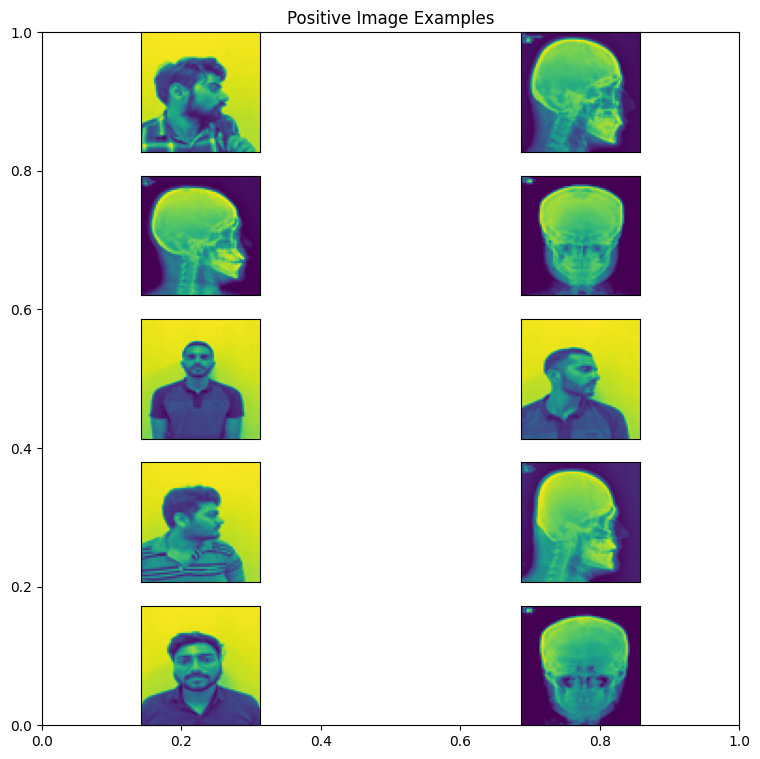

In [15]:
# Visualize Positive Images
n = 10
indices = np.where(labels_dataset == 1)[:n]
visualize(images_dataset[indices], labels_dataset[indices],
          title = "Positive Image Examples")

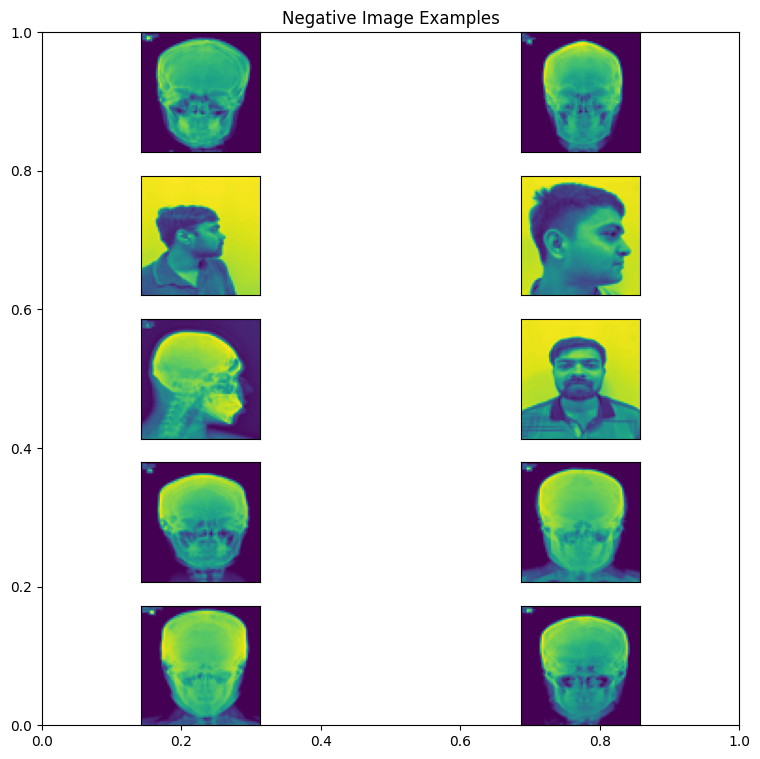

In [16]:
# Visualize Negative Images
n = 10
indices = np.where(labels_dataset == 0)[:n]
visualize(images_dataset[indices], labels_dataset[indices],
          title = "Negative Image Examples")

# Network Architecture

## Embedding Layer

In [ ]:
inputs = layers.Input((64, 64, 1))

x = layers.Conv2D(64, (10, 10), padding="same", activation="relu")(inputs)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.2)(x)

x = layers.Conv2D(128, (7, 7), padding="same", activation="relu")(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.3)(x)

x = layers.Conv2D(128, (4, 4), padding="same", activation="relu")(x)
x = layers.MaxPooling2D(pool_size=(2, 2))(x)
x = layers.Dropout(0.4)(x)

x = layers.Conv2D(256, (4, 4), padding="same", activation="relu")(x)
fcOutput = layers.Flatten()(x)
fcOutput = layers.Dense(4096, activation = "relu")(fcOutput)
outputs = layers.Dense(1024, activation = "sigmoid")(fcOutput)

embedding = Model(inputs, outputs, name = "Embedding")

In [17]:
from tensorflow.keras import layers, models
from tensorflow.keras.applications import VGG16
from tensorflow.keras.applications import ResNet152

# Adjust input shape for VGG16
# Since VGG16 expects (224, 224, 3), we need to convert (64, 64, 1) grayscale to (64, 64, 3)
inputs = layers.Input((64, 64, 1))

# Replicate the grayscale channel into 3 channels (RGB-like input for VGG16)
x = layers.Conv2D(3, (1, 1), padding="same")(inputs)  # This will "fake" RGB input for VGG16

# Load the VGG16 model without the top fully connected layers
base_model = ResNet152(weights='imagenet', include_top=False, input_shape=(64, 64, 3))
#base_model = EfficientNet(weights='imagenet', include_top=False, input_shape=(64, 64, 3))
# Freeze the layers of VGG16 so that only the custom top layers will be trained
base_model.trainable = True

# Pass the input through the VGG16 base model
x = base_model(x)

# Flatten the output of VGG16
x = layers.Flatten()(x)

# Add your custom fully connected layers on top
x = layers.Dense(4096, activation='relu')(x)
x = layers.Dropout(0.3)(x)  # Dropout to prevent overfitting

# Final output layer with 1024 units and sigmoid activation
outputs = layers.Dense(1024, activation='sigmoid')(x)

# Create the model
#embedding_model = models.Model(inputs, outputs, name="Embedding_with_VGG16")
embedding = models.Model(inputs, outputs, name="Embedding_with_ResNet152")
# Summary of the model
embedding.summary()


234698864/234698864 ━━━━━━━━━━━━━━━━━━━━ 7s 0us/step


Model: "Embedding_with_ResNet152"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)             │ (None, 64, 64, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 64, 64, 3)           │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ resnet152 (Functional)               │ (None, 2, 2, 2048)          │      58,370,944 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 8192)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 4096)                │      33,558,528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 1024)                │       4,195,328 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 96,124,806 (366.69 MB)

 Trainable params: 95,973,382 (366.11 MB)

 Non-trainable params: 151,424 (591.50 KB)

In [ ]:
embedding.summary()

Model: "Embedding_with_EfficientNetV2L"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)           │ (None, 64, 64, 1)           │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 64, 64, 3)           │               6 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ efficientnetv2-l (Functional)        │ (None, 2, 2, 1280)          │     117,746,848 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 5120)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 4096)                │      20,975,616 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 4096)                │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1024)                │       4,195,328 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 142,917,798 (545.19 MB)

 Trainable params: 142,405,222 (543.23 MB)

 Non-trainable params: 512,576 (1.96 MB)

## Siamese Network

In [18]:
import tensorflow.keras.backend as K

In [19]:
# Define the Contrastive Loss
def contrastive_loss(y, preds, margin=1):
    y = tf.cast(y, preds.dtype)
    squaredPreds = K.square(preds)
    squaredMargin = K.square(K.maximum(margin - preds, 0))
    loss = K.mean(y * squaredPreds + (1 - y) * squaredMargin)

    return loss

In [20]:
# Distance Layer
class DistanceLayer(layers.Layer):
    """
    This layer is responsible for computing the distance
    between the embeddings
    """

    def __init__(self, **kwargs):
        super().__init__(**kwargs)

    def call(self, anchor, compare):
        sum_squared = K.sum(K.square(anchor - compare), axis=1, keepdims=True)
        return K.sqrt(K.maximum(sum_squared, K.epsilon()))

In [21]:
anchor_input = layers.Input(name="anchor", shape=target_shape + (1,))
compare_input = layers.Input(name="compare", shape=target_shape + (1,))

distances = DistanceLayer()(
    embedding(anchor_input),
    embedding(compare_input),
)

outputs = layers.Dense(1, activation = "sigmoid") (distances)

siamese_model = Model(
    inputs=[anchor_input, compare_input], outputs=outputs
)

In [22]:
anchor_input

<KerasTensor shape=(None, 64, 64, 1), dtype=float32, sparse=None, name=anchor>

In [23]:
compare_input

<KerasTensor shape=(None, 64, 64, 1), dtype=float32, sparse=None, name=compare>

# Training

In [24]:
siamese_model.compile(loss="Crossentropy", optimizer="adam", metrics=["accuracy"])
history = siamese_model.fit([images_dataset[:, 0, :], images_dataset[:, 1, :]], labels_dataset,
                            epochs=100, validation_split = 0.2, batch_size = 32)

Epoch 1/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 452s 31s/step - accuracy: 0.4895 - loss: 0.7082 - val_accuracy: 0.4127 - val_loss: 0.6932
Epoch 2/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 59s 226ms/step - accuracy: 0.4994 - loss: 0.6947 - val_accuracy: 0.4921 - val_loss: 0.6934
Epoch 3/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 222ms/step - accuracy: 0.4695 - loss: 0.6962 - val_accuracy: 0.4444 - val_loss: 0.6937
Epoch 4/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 223ms/step - accuracy: 0.4793 - loss: 0.6962 - val_accuracy: 0.5238 - val_loss: 0.6931
Epoch 5/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 224ms/step - accuracy: 0.4687 - loss: 0.6940 - val_accuracy: 0.4444 - val_loss: 0.6943
Epoch 6/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 248ms/step - accuracy: 0.4145 - loss: 0.6941 - val_accuracy: 0.4444 - val_loss: 0.6941
Epoch 7/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 2s 235ms/step - accuracy: 0.5220 - loss: 0.6933 - val_accuracy: 0.4444 - val_loss: 0.6944
Epoch 8/100
8/8 ━━━━━━━━━━━━━━━━━━━━ 3s 231ms/step - accuracy: 0.4958 - loss: 0.6929 - val_accuracy: 0.4444 - 

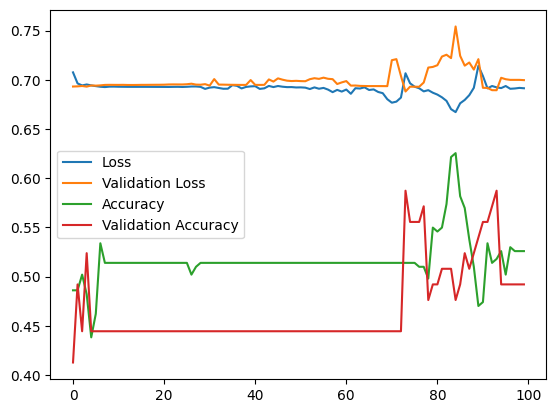

In [25]:
#Training Plot
plt.plot(history.history["loss"])
plt.plot(history.history["val_loss"])
plt.plot(history.history["accuracy"])
plt.plot(history.history["val_accuracy"])
plt.legend(["Loss", "Validation Loss", "Accuracy", "Validation Accuracy"])

# Testing

In [ ]:
def test_visualize(images, n = 5):
    """ Visualize a few images """

    def show(ax, image):
        ax.imshow(image)
        ax.get_xaxis().set_visible(False)
        ax.get_yaxis().set_visible(False)

    fig = plt.figure(figsize=(9, 9))
    axs = fig.subplots(1, n)
    for i in range(n):
        show(axs[i], images[i])

## Test 1

In [ ]:
test_indices = [0, 1, 2, 3, 4]
test_index = random.sample(range(10), 1)[0]
test_image = face_images[test_index]

compare_images = []
for i in range(5):
    index = random.sample(range(i * 10, (i + 1) * 10), 1)[0]
    image = face_images[index]
    compare_images.append(image)

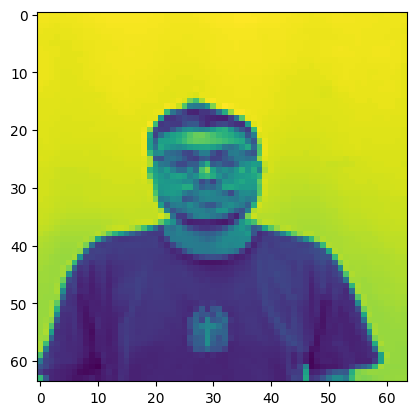

In [ ]:
plt.imshow(test_image)

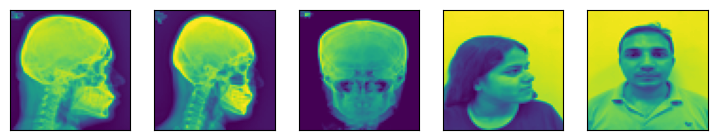

In [ ]:
test_visualize(compare_images)

In [ ]:
image_pairs = []

for image in compare_images:
    image_pairs.append((test_image, image))

image_pairs = np.array(image_pairs)

In [ ]:
score = siamese_model.predict([image_pairs[:, 0, :], image_pairs[:, 1, :]])

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


In [ ]:
print(score)

[[0.45657924]
 [0.45657924]
 [0.45657924]
 [0.45657924]
 [0.45657924]]


## Test 2

In [ ]:
test_indices = [0, 1, 2, 3, 4]
test_index = random.sample(range(10, 20), 1)[0]
test_image = face_images[test_index]

compare_images = []
for i in range(5):
    index = random.sample(range(i * 10, (i + 1) * 10), 1)[0]
    image = face_images[index]
    compare_images.append(image)

In [ ]:
plt.imshow(test_image)

In [ ]:
test_visualize(compare_images)

In [ ]:
image_pairs = []

for image in compare_images:
    image_pairs.append((test_image, image))

image_pairs = np.array(image_pairs)

In [ ]:
score = siamese_model.predict([image_pairs[:, 0, :], image_pairs[:, 1, :]])

In [ ]:
print(score)